In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    'household_power_consumption.txt',
    sep=';',
    parse_dates=[[0, 1]],
    infer_datetime_format=True,
    low_memory=False,
    na_values=['?'],
    dtype={'Global_active_power': 'float'}
)

In [3]:
df.rename(columns={'Date_Time': 'Datetime'}, inplace=True)
df.dropna(inplace=True)
df.set_index('Datetime', inplace=True)

In [4]:
df_hourly = df['Global_active_power'].resample('H').mean()
df_daily = df['Global_active_power'].resample('D').mean()

df_daily.to_csv('daily_energy_usage.csv')

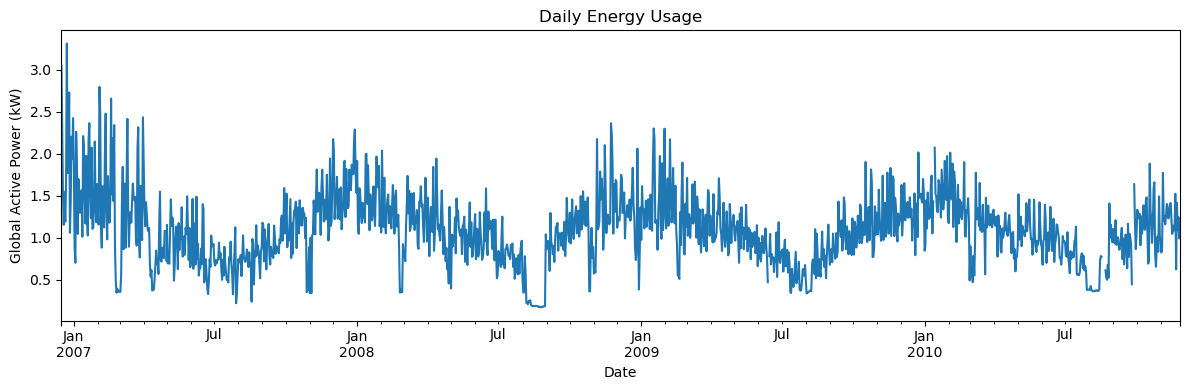

In [5]:
plt.figure(figsize=(12, 4))
df_daily.plot()
plt.title("Daily Energy Usage")
plt.ylabel("Global Active Power (kW)")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig("daily_usage_plot.png")
plt.show()